In [ ]:
print("hello")

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 100

data = pd.DataFrame({
    "date": pd.date_range("2024-01-01", periods=n),
    "pm25": np.random.normal(60, 15, n),         # air pollution
    "temperature": np.random.normal(25, 5, n),   # weather
    "mobility": np.random.normal(100, 20, n)     # human activity
})

data.head()

,date,pm25,temperature,mobility
0,2024-01-01,67.450712,17.923146,107.155747
1,2024-01-02,57.926035,22.896773,111.215691
2,2024-01-03,69.715328,23.286427,121.661025
3,2024-01-04,82.845448,20.988614,121.076041
4,2024-01-05,56.487699,24.193571,72.446613


In [2]:
data[["pm25","temperature","mobility"]].corr()

,pm25,temperature,mobility
pm25,1.000000,-0.136422,0.190840
temperature,-0.136422,1.000000,-0.036632
mobility,0.190840,-0.036632,1.000000


In [6]:
numeric_data = data.select_dtypes(include=['number'])
numeric_data.head()

,pm25,temperature,mobility
0,67.450712,17.923146,107.155747
1,57.926035,22.896773,111.215691
2,69.715328,23.286427,121.661025
3,82.845448,20.988614,121.076041
4,56.487699,24.193571,72.446613


In [7]:
corr = numeric_data.corr()
corr

,pm25,temperature,mobility
pm25,1.000000,-0.136422,0.190840
temperature,-0.136422,1.000000,-0.036632
mobility,0.190840,-0.036632,1.000000


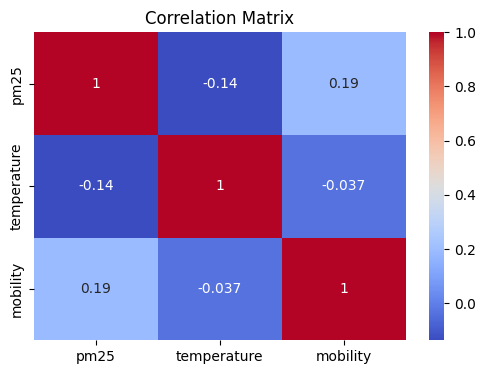

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [19]:
import pandas as pd

train = pd.read_csv("train.csv")
train.head()

/tmp/ipykernel_2502/3212134606.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


,Id,County,Province_State,Country_Region,Population,Weight,Date,Target,TargetValue
0,1,NaN,NaN,Afghanistan,27657145,0.058359,2020-01-23,ConfirmedCases,0
1,2,NaN,NaN,Afghanistan,27657145,0.583587,2020-01-23,Fatalities,0
2,3,NaN,NaN,Afghanistan,27657145,0.058359,2020-01-24,ConfirmedCases,0
3,4,NaN,NaN,Afghanistan,27657145,0.583587,2020-01-24,Fatalities,0
4,5,NaN,NaN,Afghanistan,27657145,0.058359,2020-01-25,ConfirmedCases,0


In [20]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969640 entries, 0 to 969639
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              969640 non-null  int64  
 1   County          880040 non-null  object 
 2   Province_State  917280 non-null  object 
 3   Country_Region  969640 non-null  object 
 4   Population      969640 non-null  int64  
 5   Weight          969640 non-null  float64
 6   Date            969640 non-null  object 
 7   Target          969640 non-null  object 
 8   TargetValue     969640 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 66.6+ MB


In [21]:
train.columns

Index(['Id', 'County', 'Province_State', 'Country_Region', 'Population',
       'Weight', 'Date', 'Target', 'TargetValue'],
      dtype='object')

In [24]:
X = train.drop(columns=["TargetValue"])
y = train["TargetValue"]

In [25]:
y.value_counts()

,count
TargetValue,
0,806895
1,47808
2,21279
3,12425
4,8620
...,...
5386,1
4583,1
4451,1


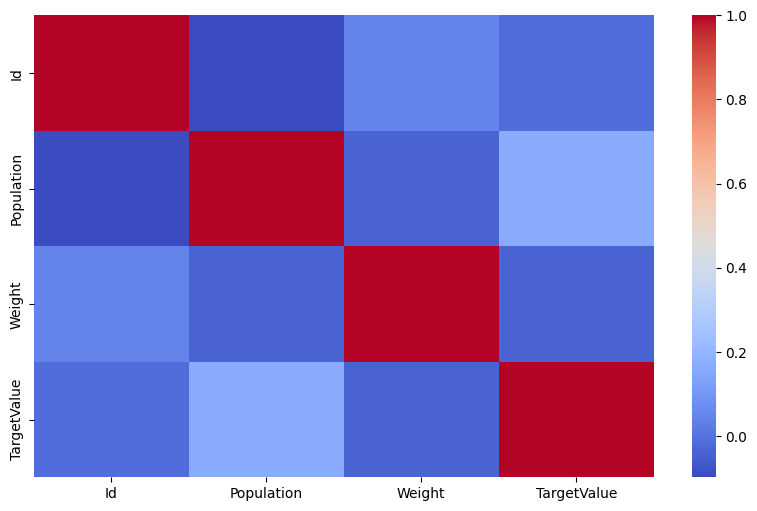

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric = train.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), cmap="coolwarm")
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = numeric.drop(columns=["TargetValue"])
y = numeric["TargetValue"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_val, y_val))

0.018022234075692256


In [28]:
train.columns

Index(['Id', 'County', 'Province_State', 'Country_Region', 'Population',
       'Weight', 'Date', 'Target', 'TargetValue'],
      dtype='object')

In [29]:
train["Date"] = pd.to_datetime(train["Date"])

In [30]:
train["TargetValue"].describe()

,TargetValue
count,969640.000000
mean,12.563518
std,302.524795
min,-10034.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,36163.000000


In [31]:
train.groupby("Province_State")["TargetValue"].mean().sort_values(ascending=False)

,TargetValue
Province_State,
Hubei,257.807143
Quebec,208.650000
Ontario,126.742857
New Jersey,57.668019
Massachusetts,53.061190
...,...
Saint Barthelemy,0.021429
Northwest Territories,0.017857
Anguilla,0.010714


<Axes: xlabel='Date'>

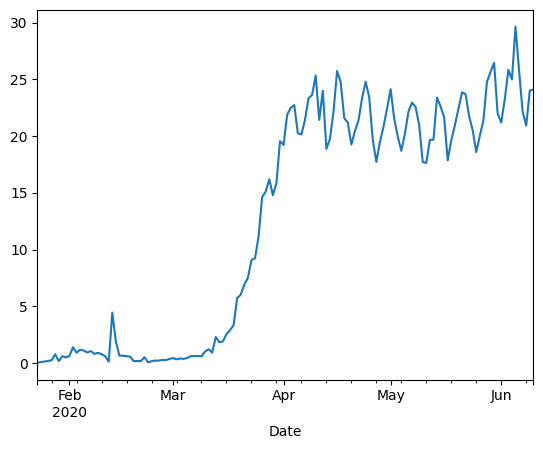

In [32]:
train.groupby("Date")["TargetValue"].mean().plot()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = ["Population", "Weight"]

X = train[features]
y = train["TargetValue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.458115010176532

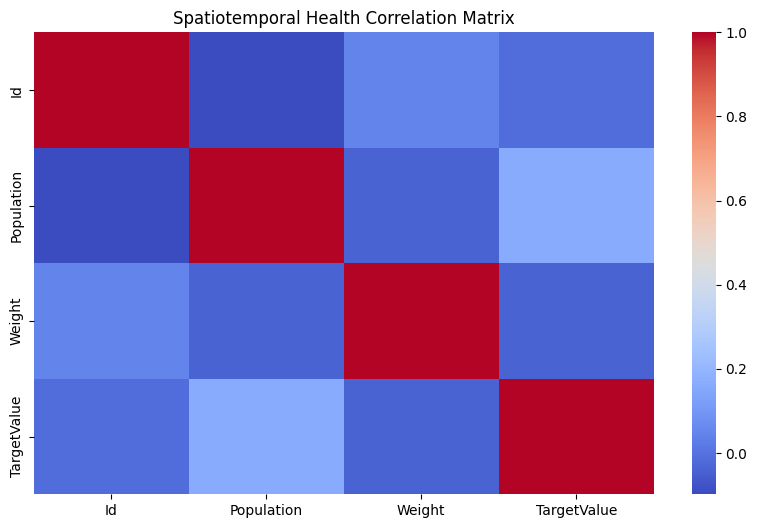

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric = train.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), cmap="coolwarm")
plt.title("Spatiotemporal Health Correlation Matrix")
plt.show()

In [36]:
import os
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/correlation.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [37]:
import os

os.listdir("figures")

['correlation.png']

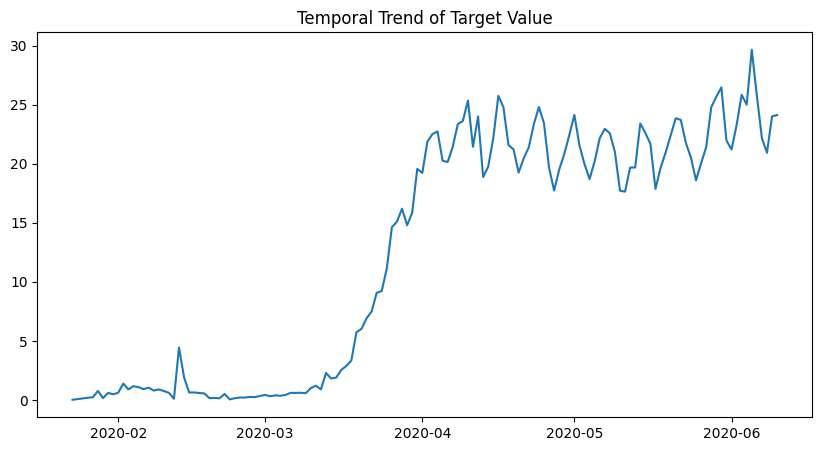

In [38]:
train["Date"] = pd.to_datetime(train["Date"])

daily = train.groupby("Date")["TargetValue"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily)
plt.title("Temporal Trend of Target Value")
plt.show()

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = train[["Population", "Weight"]]
y = train["TargetValue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

print("R2 score:", model.score(X_test, y_test))

R2 score: 0.4343883495330634
